<a target="_blank" href="https://colab.research.google.com/github/fintech-dl-hse/course/blob/main/seminars/07_vae_diffusion/07_vae_diffusion.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Семинар 7: AE, VAE, Diffusion

## AutoEncoder

**Автоэнкодер** — модель из двух частей: **encoder** переводит вход в компактное представление (латент), **decoder** по латенту восстанавливает вход. Задача обучения — минимизировать **reconstruction loss** (например, MSE или L1 между входом и выходом). Узкое место между encoder и decoder (bottleneck) заставляет модель выделять главные признаки.

Классические автоэнкодеры ([Hinton & Salakhutdinov, 2006](https://www.cs.toronto.edu/~hinton/science.pdf)) использовались для предобучения и сжатия; сейчас их применяют для генерации (интерполяция в латенте), детекции аномалий и как часть более сложных моделей.

In [2]:
from torchvision.datasets import MNIST
import torchvision.transforms as transformsv1

import torch.nn as nn
from torch.optim import Adam
import torch
import torch.utils.data
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

In [3]:
transforms = transformsv1.Compose([
    transformsv1.ToTensor(),
])

mnist_dataset = MNIST("./MNIST", download=True, transform=transforms)

len(mnist_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


60000

In [4]:
class ImageEncoder(nn.Module):
    """Свёрточный encoder: изображение [B, 1, 28, 28] -> латент [B, latent_dim*14*14]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 64, kernel_size=3, padding=1),   # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [ bs, 128, 28, 28 ]
            nn.MaxPool2d(2),                              # [ bs, 128, 14, 14 ]
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, self.latent_dim, kernel_size=1),     # [ bs, latent_dim, 14, 14 ]
            nn.Flatten(1),
        ])

    def forward(self, images_batch):
        return self.sequential(images_batch)


class ImageDecoder(nn.Module):
    """Свёрточный decoder: латент [B, latent_dim*14*14] -> изображение [B, 1, 28, 28]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.Unflatten(1, (self.latent_dim, 14, 14)),
            nn.BatchNorm2d(self.latent_dim),
            nn.Conv2d(128, 64, kernel_size=1), # [ bs, 64, 14, 14 ]
            nn.Upsample([28, 28]),             # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.Sigmoid(),
        ])

    def forward(self, image_embedding):
        # image_embedding ~ [ bs, 128 ]
        # print("image_embedding", image_embedding.shape)
        assert len(image_embedding.shape) == 2
        assert image_embedding.shape[1] == self.latent_dim * 14 * 14, f"{image_embedding.shape[1]} == {self.latent_dim}"
        # image_embedding = image_embedding.reshape(-1, self.latent_dim)
        return self.sequential(image_embedding)



In [5]:
class AutoEncoder(nn.Module):
    """Автоэнкодер: encoder + decoder, forward возвращает восстановленное изображение."""

    def __init__(self):
        super().__init__()

        self.encoder = ImageEncoder()
        self.decoder = ImageDecoder()

    def encode(self, images_batch):
        return self.encoder(images_batch)

    def decode(self, images_embeddings):
        return self.decoder(images_embeddings)

    def forward(self, images_batch):
        images_embeddings = self.encode(images_batch)
        # if self.training:
        #     images_embeddings += torch.randn_like(images_embeddings)
        return self.decode(images_embeddings)



In [6]:
mnist_dataset[0][0].shape

torch.Size([1, 28, 28])

In [7]:
AutoEncoder().forward( torch.rand( [ 5, 1, 28, 28 ] ) ).shape

torch.Size([5, 1, 28, 28])

In [8]:
def train(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    loss_function: nn.Module,
    num_epochs: int = 10,
    device: str = "cuda",
    learning_rate: float = 3e-4,
) -> None:
    """
    Обучает модель (AE/VAE) на датасете с разделением на train/val.

    Args:
        model: Модель с forward(x) -> recon (и опционально mu, logvar для VAE).
        dataset: Датасет изображений.
        loss_function: Функция потерь (recon, x) или (recon, x, mu, logvar).
        num_epochs: Количество эпох.
        device: Устройство (cuda/cpu).
        learning_rate: Learning rate для Adam.
    """
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1], generator=generator)
    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=learning_rate)

    train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False)


    progress_bar = tqdm(range(num_epochs), total=num_epochs, desc="Epoch")
    for epoch_num in progress_bar:

        # train dataloader
        train_losses_sum = torch.tensor([0.0], device=device)
        train_iterations = 0
        for images_batch in train_dataloader:
            images_batch = images_batch[0].to(device)

            restored_images_batch = model(images_batch)

            loss = loss_function(restored_images_batch, images_batch)

            train_losses_sum += loss.detach()
            train_iterations += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validation
        val_losses_sum = torch.tensor([0.0], device=device)
        valid_iterations = 0
        with torch.no_grad():
            for images_batch in val_dataloader:
                images_batch = images_batch[0].to(device)

                valid_iterations += 1
                restored_images_batch = model(images_batch)
                loss = loss_function(restored_images_batch, images_batch)

                val_losses_sum += loss.mean()

        mean_val_loss = (val_losses_sum / valid_iterations).item()
        mean_train_loss = (train_losses_sum / train_iterations).item()
        progress_bar.set_postfix({"val_loss": f"{mean_val_loss:.2f}", "train_loss": f"{mean_train_loss:.2f}"})
        # print(f"epoch {epoch_num} val_loss={mean_val_loss}")




In [9]:
autoencoder = AutoEncoder()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

generator = torch.Generator().manual_seed(42)

# cfair_dataset_5p, _ = torch.utils.data.random_split(cfair_dataset, [0.1, 0.9], generator=generator)
# print("cfair_dataset_5p", len(cfair_dataset_5p))
train(autoencoder, mnist_dataset, nn.L1Loss(), device=device, num_epochs=10, learning_rate=3e-4)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
@torch.no_grad()
def linear_latent_space_interpolation(
    model: nn.Module,
    image_from: torch.Tensor,
    image_to: torch.Tensor,
    device: str = "cpu",
    num_interpolation_steps: int = 10,
) -> list:
    """
    Строит линейную интерполяцию между двумя изображениями в латентном пространстве модели.

    Args:
        model: Модель с методами encode и decode.
        image_from: Исходное изображение (без batch).
        image_to: Конечное изображение.
        device: Устройство.
        num_interpolation_steps: Количество шагов интерполяции.

    Returns:
        Список массивов восстановленных изображений по шагам.
    """
    model.eval()
    image_from = image_from.unsqueeze(0).to(device)
    image_to = image_to.unsqueeze(0).to(device)
    model = model.to(device)

    latent_space_from = model.encode(image_from)
    latent_space_to = model.encode(image_to)

    latent_space_steps = torch.linspace(0, 1, num_interpolation_steps)

    latent_diff = latent_space_to - latent_space_from

    restored_images = []
    for latent_step_portion in latent_space_steps:
        latent_step = latent_diff * latent_step_portion
        latent_interpolation = latent_space_from + latent_step

        restored_image = model.decode(latent_interpolation).detach().clip(0, 1).cpu().numpy()[0]
        restored_images.append(restored_image)

    return restored_images

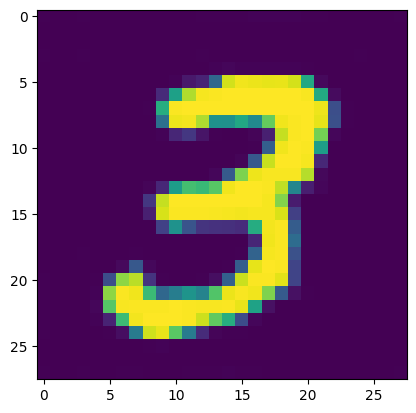

In [11]:
autoencoder.eval()
zero_autoencoder_prediction = autoencoder(mnist_dataset[7][0].unsqueeze(0).to(device))
plt.imshow(zero_autoencoder_prediction.permute(0, 2, 3, 1).detach().cpu().numpy()[0])

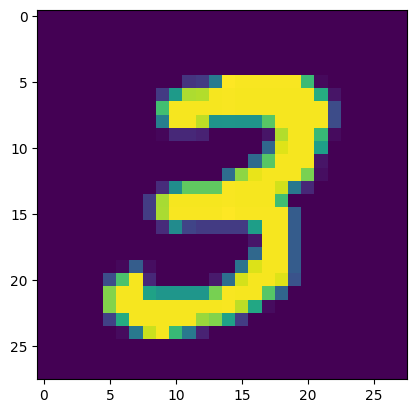

In [12]:
plt.imshow(mnist_dataset[7][0].permute(1,2, 0).numpy())

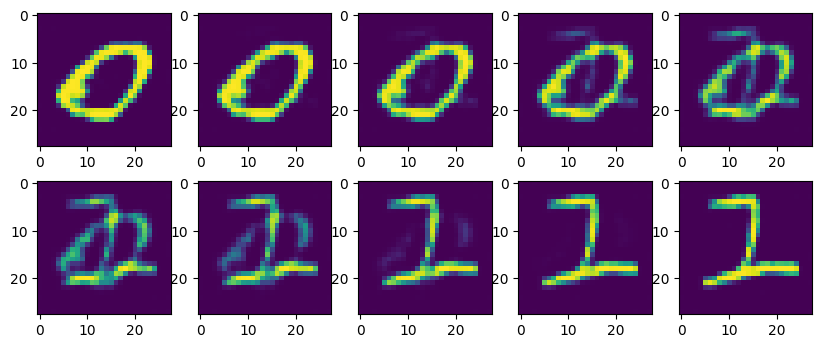

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

autoencoder_interpolated = linear_latent_space_interpolation(
    autoencoder, mnist_dataset[1][0], mnist_dataset[2][0],
    device=device,
    num_interpolation_steps=10
)

_, axs = plt.subplots(2, 5, figsize=(10, 4))
axs = axs.flatten()
for img, ax in zip(autoencoder_interpolated, axs):
    ax.imshow(img.T)
plt.show()

---

<img src="static/ae_vae.png" width=400 />

## VAE (Variational AutoEncoder)

**Мотивация:** У обычного AE латентное пространство может быть «рваным»: близкие точки в латенте не обязательно дают похожие изображения. Генерация как сэмплирование из латента ненадёжна. **VAE** [Kingma & Welling, 2013](https://arxiv.org/abs/1312.6114) моделирует латент как случайную величину с нормальным распределением $q_\phi(z|x)$ (encoder выдаёт $\mu$ и $\log\sigma^2$), а декодер восстанавливает $x$ из $z$.

**ELBO:** Максимизируем нижнюю оценку правдоподобия (Evidence Lower BOund):

$$ \mathcal{L} = \mathbb{E}_{z \sim q_\phi(z|x)} \log p_\theta(x|z) - D_{KL}(q_\phi(z|x) \| p(z)) $$

Первый член — reconstruction loss (как в AE), второй — KL-дивергенция между $q_\phi(z|x)$ и априором $p(z) = \mathcal{N}(0, I)$. KL тянет латент к гладкому распределению.

**Reparametrization trick:** Сэмплирование $z \sim \mathcal{N}(\mu, \sigma^2)$ недифференцируемо по $\mu, \sigma$. Пишем $z = \mu + \sigma \cdot \epsilon$, где $\epsilon \sim \mathcal{N}(0, 1)$ — градиенты идут по $\mu$ и $\sigma$.

In [15]:
def reparametrize(mu: torch.Tensor, logvar: torch.Tensor, generator: torch.Generator | None = None) -> torch.Tensor:
    """
    Reparametrization trick: z = mu + sigma * epsilon, epsilon ~ N(0, 1).
    Позволяет backprop через сэмпл z по параметрам mu и logvar.

    Args:
        mu: Средние [B, latent_dim].
        logvar: Логарифм дисперсии [B, latent_dim].
        generator: Генератор для воспроизводимости.

    Returns:
        Сэмпл z [B, latent_dim], дифференцируемый по mu и logvar.
    """
    sigma = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(mu, generator=generator)
    return mu + sigma * epsilon


# Проверка: градиенты должны идти по mu и logvar
torch.manual_seed(42)
mu = torch.randn(2, 4, requires_grad=True)
logvar = torch.zeros(2, 4, requires_grad=True)
z = reparametrize(mu, logvar)
loss = z.sum()
loss.backward()
assert mu.grad is not None and logvar.grad is not None, "Градиенты по mu и logvar должны быть вычислены"
print("Reparametrization trick: градиенты по mu и logvar успешно вычислены.")
print("mu.grad norm:", mu.grad.norm().item())
print("logvar.grad norm:", logvar.grad.norm().item())

Reparametrization trick: градиенты по mu и logvar успешно вычислены.
mu.grad norm: 2.8284270763397217
logvar.grad norm: 1.342544436454773


---

## Diffusion

### DDPM

Код из https://github.com/tanelp/tiny-diffusion/tree/master

In [ ]:
! wget https://raw.githubusercontent.com/tanelp/tiny-diffusion/master/static/DatasaurusDozen.tsv
! mkdir static
! mv DatasaurusDozen.tsv ./static

--2025-05-26 15:49:25--  https://raw.githubusercontent.com/tanelp/tiny-diffusion/master/static/DatasaurusDozen.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64046 (63K) [text/plain]
Saving to: ‘DatasaurusDozen.tsv’

DatasaurusDozen.tsv 100%[===================>]  62.54K  --.-KB/s    in 0.003s  

2025-05-26 15:49:25 (24.0 MB/s) - ‘DatasaurusDozen.tsv’ saved [64046/64046]



In [ ]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import TensorDataset

def dino_dataset(n=8000):
    df = pd.read_csv("static/DatasaurusDozen.tsv", sep="\t")
    df = df[df["dataset"] == "dino"]

    rng = np.random.default_rng(42)
    ix = rng.integers(0, len(df), n)
    x = df["x"].iloc[ix].tolist()
    x = np.array(x) + rng.normal(size=len(x)) * 0.15
    y = df["y"].iloc[ix].tolist()
    y = np.array(y) + rng.normal(size=len(x)) * 0.15
    x = (x/54 - 1) * 4
    y = (y/48 - 1) * 4
    X = np.stack((x, y), axis=1)
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))

def get_dataset(name, n=8000):
    if name == "dino":
        return dino_dataset(n)
    else:
        raise ValueError(f"Unknown dataset: {name}")

In [ ]:
'''Different methods for positional embeddings. These are not essential for understanding DDPMs, but are relevant for the ablation study.'''

import torch
from torch import nn
from torch.nn import functional as F

class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0])) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size))
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

    def __len__(self):
        return self.size

class PositionalEmbedding(nn.Module):
    def __init__(self, size: int, type: str, **kwargs):
        super().__init__()

        if type == "sinusoidal":
            self.layer = SinusoidalEmbedding(size, **kwargs)
        else:
            raise ValueError(f"Unknown positional embedding type: {type}")

    def forward(self, x: torch.Tensor):
        return self.layer(x)

In [ ]:
# https://github.com/tanelp/tiny-diffusion/blob/master/ddpm.py

import argparse
import os

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np


class Block(nn.Module):
    def __init__(self, size: int):
        super().__init__()

        self.ff = nn.Linear(size, size)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor):
        return x + self.act(self.ff(x))


class MLP(nn.Module):
    def __init__(self, hidden_size: int = 128, hidden_layers: int = 3, emb_size: int = 128,
                 time_emb: str = "sinusoidal", input_emb: str = "sinusoidal"):
        super().__init__()

        self.time_mlp = PositionalEmbedding(emb_size, time_emb)
        self.input_mlp1 = PositionalEmbedding(emb_size, input_emb, scale=25.0)
        self.input_mlp2 = PositionalEmbedding(emb_size, input_emb, scale=25.0)

        concat_size = len(self.time_mlp.layer) + \
            len(self.input_mlp1.layer) + len(self.input_mlp2.layer)
        layers = [nn.Linear(concat_size, hidden_size), nn.GELU()]
        for _ in range(hidden_layers):
            layers.append(Block(hidden_size))
        layers.append(nn.Linear(hidden_size, 2))
        self.joint_mlp = nn.Sequential(*layers)

    def forward(self, x, t):
        # x ~ [ bs, 2 ]
        # Если поменяем батч сайз, то все может сломается
        x1_emb = self.input_mlp1(x[:, 0])
        x2_emb = self.input_mlp2(x[:, 1])
        t_emb = self.time_mlp(t)
        x = torch.cat((x1_emb, x2_emb, t_emb), dim=-1)
        x = self.joint_mlp(x)
        return x

class NoiseScheduler():
    def __init__(self,
                 num_timesteps=1000,
                 beta_start=0.0001,
                 beta_end=0.02,
                 beta_schedule="linear"):

        self.num_timesteps = num_timesteps
        if beta_schedule == "linear":
            self.betas = torch.linspace(
                beta_start, beta_end, num_timesteps, dtype=torch.float32)
        elif beta_schedule == "quadratic":
            self.betas = torch.linspace(
                beta_start ** 0.5, beta_end ** 0.5, num_timesteps, dtype=torch.float32) ** 2

        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(
            self.alphas_cumprod[:-1], (1, 0), value=1.)

        # required for self.add_noise
        self.sqrt_alphas_cumprod = self.alphas_cumprod ** 0.5
        self.sqrt_one_minus_alphas_cumprod = (1 - self.alphas_cumprod) ** 0.5

        # required for reconstruct_x0
        self.sqrt_inv_alphas_cumprod = torch.sqrt(1 / self.alphas_cumprod)
        self.sqrt_inv_alphas_cumprod_minus_one = torch.sqrt(
            1 / self.alphas_cumprod - 1)

        # required for q_posterior
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)

    def reconstruct_x0(self, x_t, t, noise):
        s1 = self.sqrt_inv_alphas_cumprod[t]
        s2 = self.sqrt_inv_alphas_cumprod_minus_one[t]
        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)
        return s1 * x_t - s2 * noise

    def q_posterior(self, x_0, x_t, t):
        s1 = self.posterior_mean_coef1[t]
        s2 = self.posterior_mean_coef2[t]
        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)
        mu = s1 * x_0 + s2 * x_t
        return mu

    def get_variance(self, t):
        if t == 0:
            return 0

        variance = self.betas[t] * (1. - self.alphas_cumprod_prev[t]) / (1. - self.alphas_cumprod[t])
        variance = variance.clip(1e-20)
        return variance

    # Implemets step from
    # https://arxiv.org/pdf/2208.11970
    # Sampling
    def step(self, model_output, timestep, sample):
        t = timestep
        pred_original_sample = self.reconstruct_x0(sample, t, model_output)
        # TODO должно ли быть на t-1
        pred_prev_sample = self.q_posterior(pred_original_sample, sample, t)

        variance = 0
        if t > 0:
            noise = torch.randn_like(model_output)
            variance = (self.get_variance(t) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample

    # Train
    def add_noise(self, x_start, x_noise, timesteps):
        s1 = self.sqrt_alphas_cumprod[timesteps]
        s2 = self.sqrt_one_minus_alphas_cumprod[timesteps]

        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)

        return s1 * x_start + s2 * x_noise

    def __len__(self):
        return self.num_timesteps

In [ ]:
from dataclasses import dataclass

@dataclass
class TraniningConfig():
    experiment_name ="base"
    dataset ="dino" # choices=["circle", "dino", "line", "moons"]
    train_batch_size = 32
    eval_batch_size = 1000
    num_epochs = 200
    learning_rate = 1e-3
    num_timesteps = 1000
    beta_schedule = "linear" # choices=["linear", "quadratic"]
    embedding_size = 128
    hidden_size = 128
    hidden_layers = 3
    time_embedding = "sinusoidal" # choices=["sinusoidal", "learnable", "linear", "zero"])
    input_embedding = "sinusoidal" # choices=["sinusoidal", "learnable", "linear", "identity"])
    save_images_step = 5

config = TraniningConfig()

dataset = get_dataset(config.dataset)
dataloader = DataLoader(
    dataset, batch_size=config.train_batch_size, shuffle=True, drop_last=True)


model = MLP(
    hidden_size=config.hidden_size,
    hidden_layers=config.hidden_layers,
    emb_size=config.embedding_size,
    time_emb=config.time_embedding,
    input_emb=config.input_embedding)

noise_scheduler = NoiseScheduler(
    num_timesteps=config.num_timesteps,
    beta_schedule=config.beta_schedule)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
)

### Рекуррентная ф-ла для вычисления $x_t$

$$ x_t = \sqrt{ \alpha_t} \ x_{t-1} + \sqrt{1 - \alpha_t} \  \epsilon $$

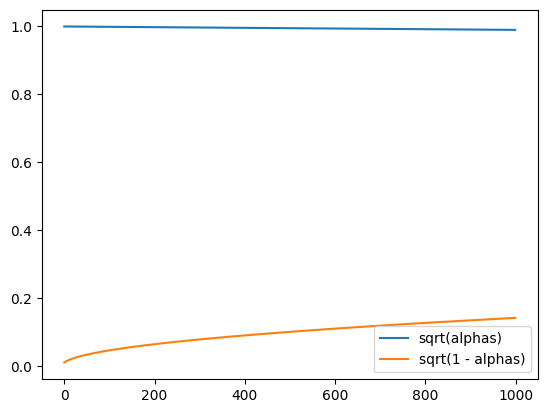

In [ ]:
import matplotlib.pyplot as plt

plt.plot( torch.sqrt(noise_scheduler.alphas), label="sqrt(alphas)" )
plt.plot( torch.sqrt(1 - noise_scheduler.alphas), label="sqrt(1 - alphas)" )

plt.legend()

### Нерекуррентная ф-ла для вычисления $x_t$

$$ x_t = \sqrt{ \overline{\alpha_t} } \ x_0 + \sqrt{1 - \overline{\alpha_t}} \  \epsilon $$

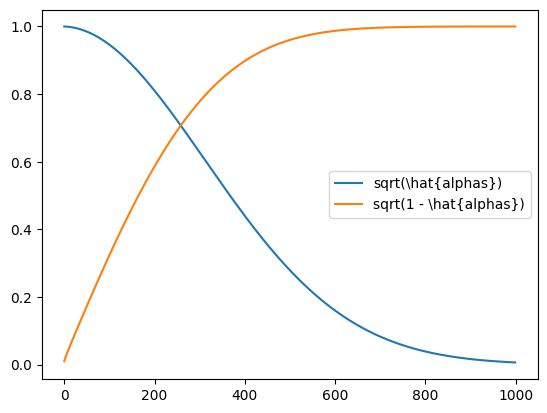

In [ ]:
plt.plot( noise_scheduler.sqrt_alphas_cumprod, label="sqrt(\overline{alphas})" )
plt.plot( noise_scheduler.sqrt_one_minus_alphas_cumprod, label="sqrt(1 - \overline{alphas})" )

plt.legend()

In [ ]:


global_step = 0
frames = []
losses = []
print("Training model...")
for epoch in range(config.num_epochs):
    model.train()
    progress_bar = tqdm(total=len(dataloader))
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in enumerate(dataloader):
        batch = batch[0] # [ bs, 2 ]
        noise = torch.rand_like(batch) # [ bs, 2 ]
        timesteps = torch.randint(
            0, noise_scheduler.num_timesteps, (batch.shape[0],)
        ).long()

        noisy = noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = model(noisy, timesteps)
        loss = F.mse_loss(noise_pred, noise)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        logs = {"loss": loss.detach().item(), "step": global_step}
        losses.append(loss.detach().item())
        progress_bar.set_postfix(**logs)
        global_step += 1
    progress_bar.close()

    if epoch % config.save_images_step == 0 or epoch == config.num_epochs - 1:
        # generate data with the model to later visualize the learning process
        model.eval()
        sample = torch.randn(config.eval_batch_size, 2)
        timesteps = list(range(len(noise_scheduler)))[::-1]
        for i, t in enumerate(tqdm(timesteps)):
            t = torch.from_numpy(np.repeat(t, config.eval_batch_size)).long()
            with torch.no_grad():
                residual = model(sample, t)
            sample = noise_scheduler.step(residual, t[0], sample)
        frames.append(sample.numpy())

print("Saving model...")
outdir = f"exps/{config.experiment_name}"
os.makedirs(outdir, exist_ok=True)
torch.save(model.state_dict(), f"{outdir}/model.pth")

print("Saving images...")
imgdir = f"{outdir}/images"
os.makedirs(imgdir, exist_ok=True)
frames = np.stack(frames)
xmin, xmax = -6, 6
ymin, ymax = -6, 6
for i, frame in enumerate(frames):
    plt.figure(figsize=(10, 10))
    plt.scatter(frame[:, 0], frame[:, 1])
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.savefig(f"{imgdir}/{i:04}.png")
    plt.close()

print("Saving loss as numpy array...")
np.save(f"{outdir}/loss.npy", np.array(losses))

print("Saving frames...")
np.save(f"{outdir}/frames.npy", frames)

<img src="static/img_0.png" width=400 />

## Еще материалы про диффузионные модели

 - [The Annotated Diffusion Model](https://huggingface.co/blog/annotated-diffusion)
 - [Diffusion Models From Scratch](https://github.com/tonyduan/diffusion/tree/main)
 - [Diffusers](https://github.com/huggingface/diffusers/)
 - [Классная лекция](https://www.youtube.com/watch?v=YeS3Td5O1kU) от AIRI по введению в диффузионки




## Блиц

### VAE

#### ❓ **Вопрос**: Чем `AutoEncoder` отличается от `VariationalAutoEncoder`? Какая мотивация?

<details>

<summary><strong>Ответ</strong></summary>

VAE задаёт латент как распределение (обычно гауссово) и обучается с ELBO: reconstruction + KL-регуляризация к $p(z)$. Из-за этого латентное пространство становится более гладким и непрерывным — интерполяция и сэмплирование дают осмысленные объекты. У обычного AE латент не регуляризован, «дыры» между кодами могут давать артефакты. Генерация в VAE: сэмплируем $z \sim \mathcal{N}(0, I)$ и прогоняем через декодер.</br>

</details>


#### ❓ **Вопрос**: Как можно использовать `AutoEncoder` для задачи поиска аномалий? Какой из вариантов автоэнкодера для этого лучше всего подходит?

<details>

<summary><strong>Ответ</strong></summary>

Смотрим на ошибку декодера. Если декодер плохо восстанавливает данные, значит этого сэмпла не было в исходной выборке, на которой мы обучились, и это скорее всего выброс.</br>

</details>


#### ❓ **Вопрос**: Автоэнкодеры — это генеративная модель? Можно ли запустить генерацию чего-либо через автоэнкодеры? Как ей управлять?

<details>

<summary><strong>Ответ</strong></summary>

Да, можно. Управлять генерацией можно через интерполяцию в латентном пространстве или сэмплирование из латента (в VAE — сэмплируем $z \sim \mathcal{N}(0, I)$ и подаём в декодер).</br>

</details>


#### ❓ **Вопрос**: Какие метрики качества можно использовать во время обучения автоэнкодеров?

<details>

<summary><strong>Ответ</strong></summary>

FID, IS (Inception Score). Обе метрики используют фичи/предсказания предобученной сети (Inception) и не требуют ручной разметки.</br>

</details>


#### ❓ **Вопрос**: Что такое reparametrization trick? Какую проблему он решает?

<details>

<summary><strong>Ответ</strong></summary>

Решает проблему распространения градиентов.</br>
Если мы просто сэмплируем из распределения с заданными параметрами — не понятно, как распространять градиенты.</br>

<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/06_vae_gan/static/img_3.png" width=400 /></br>

</details>


---

### Diffusion

#### ❓ **Вопрос**: Зачем в диффузии нужно большое количество шагов?

<details>

<summary><strong>Ответ</strong></summary>

С меньшим кол-вом шагов работает хуже или не работает. Рекомендуется ~ 1к шагов для обучения. Но вообще говоря, после обучения можно дистиллировать модель в меньшее кол-во шагов (см. Progressive Distillation, например).</br>

</details>


#### ❓ **Вопрос**: Что такое прямой процесс диффузии? Чем отличается от обратного?

<details>

<summary><strong>Ответ</strong></summary>

Во время прямого процесса диффузии мы зашумляем картинку. Используется только во время обучения и не последовательно по шагам, и для любого $x_0$ мы можем вычислить $x_t$ в идеале за константу.</br>
Во время обратного процесса диффузии мы восстанавливаем сэмпл из шума, используя обученную модель.</br>

</details>


#### ❓ **Вопрос**: Почему для диффузии важно, чтобы $x_t \sim q_t(x_t | x_0)$ (ф-ия `.add_noise`) можно было вычислять эффективно?

<details>

<summary><strong>Ответ</strong></summary>

Потому что во время обучения этот метод вызывается большое количество раз.</br>
В теории можно заранее насэмплировать большой датасет с зашумлением на разных шагах, но это потребует большого количества диска.</br>

</details>


#### ❓ **Вопрос**: Какие недостатки есть у диффузионных моделей? Как с ними можно бороться?

<details>

<summary><strong>Ответ</strong></summary>

Долгий сэмплинг → бороться через дистилляцию, квантизацию или прунинг.</br>

</details>



#### ❓ **Вопрос**: Как механизм внимания можно применить в диффузионных моделях?

<details>

<summary><strong>Ответ</strong></summary>

В контексте изображений, например, так же как в ViT — для моделирования взаимодействия между разными патчами изображения.</br>

</details>


#### ❓ **Вопрос**: Что такое importance sampling в контексте диффузионок? Какую проблему он решает? Как влияет на обучение?

<details>

<summary><strong>Ответ</strong></summary>

Timestep Importance Sampling используется для ускорения обучения.</br>
Обычно на больших значениях $t$ обучить модель сложнее, чем на маленьких (когда уже есть много информации в самом сэмпле). Поэтому на больших $t$ нужно больше примеров.</br>
Importance Sampling управляет частотой сэмплирования таймстепов так, что для таймстепов с большими значениями лосса выдаются большие частоты.</br>

</details>


#### ❓ **Вопрос**: Как можно было бы сделать диффузию в дискретном пространстве?

<details>

<summary><strong>Ответ</strong></summary>

Аналогично VQ-VAE — можно перейти в дискретное скрытое пространство.</br>
В этом случае для прямого процесса диффузии используется матрица переходов.</br>
Общий подход к диффузии сохраняется таким же, как для непрерывной диффузии в контексте скрытого пространства (не путать с непрерывной диффузией в контексте таймстепов — см. «Continuous-Time Diffusion»).</br>
Если интересна эта тема: [VQ-Diffusion](https://github.com/microsoft/VQ-Diffusion/tree/main).</br>

</details>

#### ❓ **Вопрос**: Что является результатом вычисления `.forward()` для диффузионки?

<details>

<summary><strong>Ответ</strong></summary>

Обычно предсказывается шум, который надо вычесть из сэмпла.</br>
Но есть разные стратегии: можно предсказывать шум; можно предсказывать предыдущий сэмпл $x_{t-1}$; можно предсказывать исходный сэмпл $x_0$.</br>

</details>


#### ❓ **Вопрос**: На каких слоях и как используются timestep'ы в диффузионных моделях?

<details>

<summary><strong>Ответ</strong></summary>

Есть разные подходы: можно конкатенировать обучаемый эмбэддинг с вектором признаков и передать в MLP; можно закодировать через AdaLayerNorm — по сути добавляет смещение для сгенерированного сэмпла ([пример в diffusers](https://github.com/huggingface/diffusers/blob/fdb05f54ef61007a8f77ad8537b292176d13fafb/src/diffusers/models/normalization.py#L28)).</br>

</details>

---

## Домашки

В домашнем задании **vae** нужно реализовать и обучить VAE на датасете (например, MNIST или другом по условию).

**На что обратить внимание:**
- Корректная реализация reparametrization trick и лосса (reconstruction + KL).
- Стабильность обучения: баланс между reconstruction и KL (иногда весят KL коэффициентом $\beta$).
- Проверка генерации: сэмплирование $z \sim \mathcal{N}(0, I)$ и визуализация выходов декодера.
